## Integrantes do grupo:

- 11201811864 - Lucas Araujo Avelino Dos Santos
- 11201920812 - Vithório da Cunha Marques
- 11202231732 - Wagner Ryu Kamiya

In [ ]:
!pip install opencv-python numpy matplotlib

### Imports de código nosso
Para organizar e re-aproveitar o código extraimos as funções principais nos scripts render_pipeline.py (com código de que renderiza as imagens) e image_transformes.py (que contem funções de transformação de imagem)

In [1]:
from image_transformers import *
from render_pipeline import *

In [ ]:
sliders = [
  {"name": "gaussian_size", "min": 1, "max": 15, "initial": 5, "odd": True},
  {"name": "gaussian_sigma", "min": 1, "max": 50, "initial": 12},
  {"name": "sobel_size", "min": 1, "max": 15, "initial": 3, "odd": True},
  {"name": "sobel_scale", "min": 1, "max": 50, "initial": 20},
  {"name": "morph_size", "min": 1, "max": 15, "initial": 5, "odd": True},
  {"name": "masks", "min": 1, "max": 3, "initial": 1},
  {"name": "hue", "min": 0, "max": 255, "initial": 0},
  {"name": "mode", "min": 0, "max": 3, "initial": 0},
]

modes = [Erode, Dilate, Opening, Closing]

def buildPipeline(values):
  return [
    GaussianBlur(values["gaussian_size"], values["gaussian_sigma"] / 10),
    Sobel(values["sobel_size"], values["sobel_scale"] / 10),
    ThresholdOtsu(),
    Parallel([
      UsePrevious(0),
      UsePrevious(-1),
      WatershedMask(
        openingSize=values["morph_size"],
        sureBgIterations=100,
        distanceThreshold=0.5,
        kernelType=KernelType.ELLIPSE,
        amountOfAreas=values["masks"],
        sourceIndex=1,
        maxAreaRatio=0.35,
      ),
    ]),
    [CvtColor(cv2.COLOR_RGB2HLS)] + [modes[values["mode"]](values["morph_size"], KernelType.ELLIPSE)]*2,
    AggregatorYIntoX(ParallelAggregable([
      ApplyHueWithMask(values["hue"]),
    ]), 0, [
      1, 2
    ]),
    [CvtColor(cv2.COLOR_HLS2RGB)] * 1 * 1 * 2,
  ]

hue = 255

pipeline = [
  GaussianBlur(5, 1.2),
  Sobel(3, 2.0),
  ThresholdOtsu(),
  Parallel([
    UsePrevious(0),
    WatershedMask(
      openingSize=9,
      sureBgIterations=2,
      distanceThreshold=0.25,
      kernelType=KernelType.ELLIPSE,
      amountOfAreas=1,
      sourceIndex=1,
      maxAreaRatio=0.35,
    ),
  ]),
  [CvtColor(cv2.COLOR_RGB2HLS)] + [Erode(9, KernelType.ELLIPSE)]*1,
  AggregatorYIntoX(ParallelAggregable([ApplyHueWithMask(hue)]), 0, [1]),
  [CvtColor(cv2.COLOR_HLS2RGB)] 
    * 1 
    * 1
    * 1,
]

In [3]:
RunCameraPipelineWithSliders(pipelineBuilder=buildPipeline, sliders=sliders, itemPerRow=6)

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window_w32.cpp:1261: error: (-27:Null pointer) NULL window: 'Pipeline Controls' in function 'cvDestroyWindow'


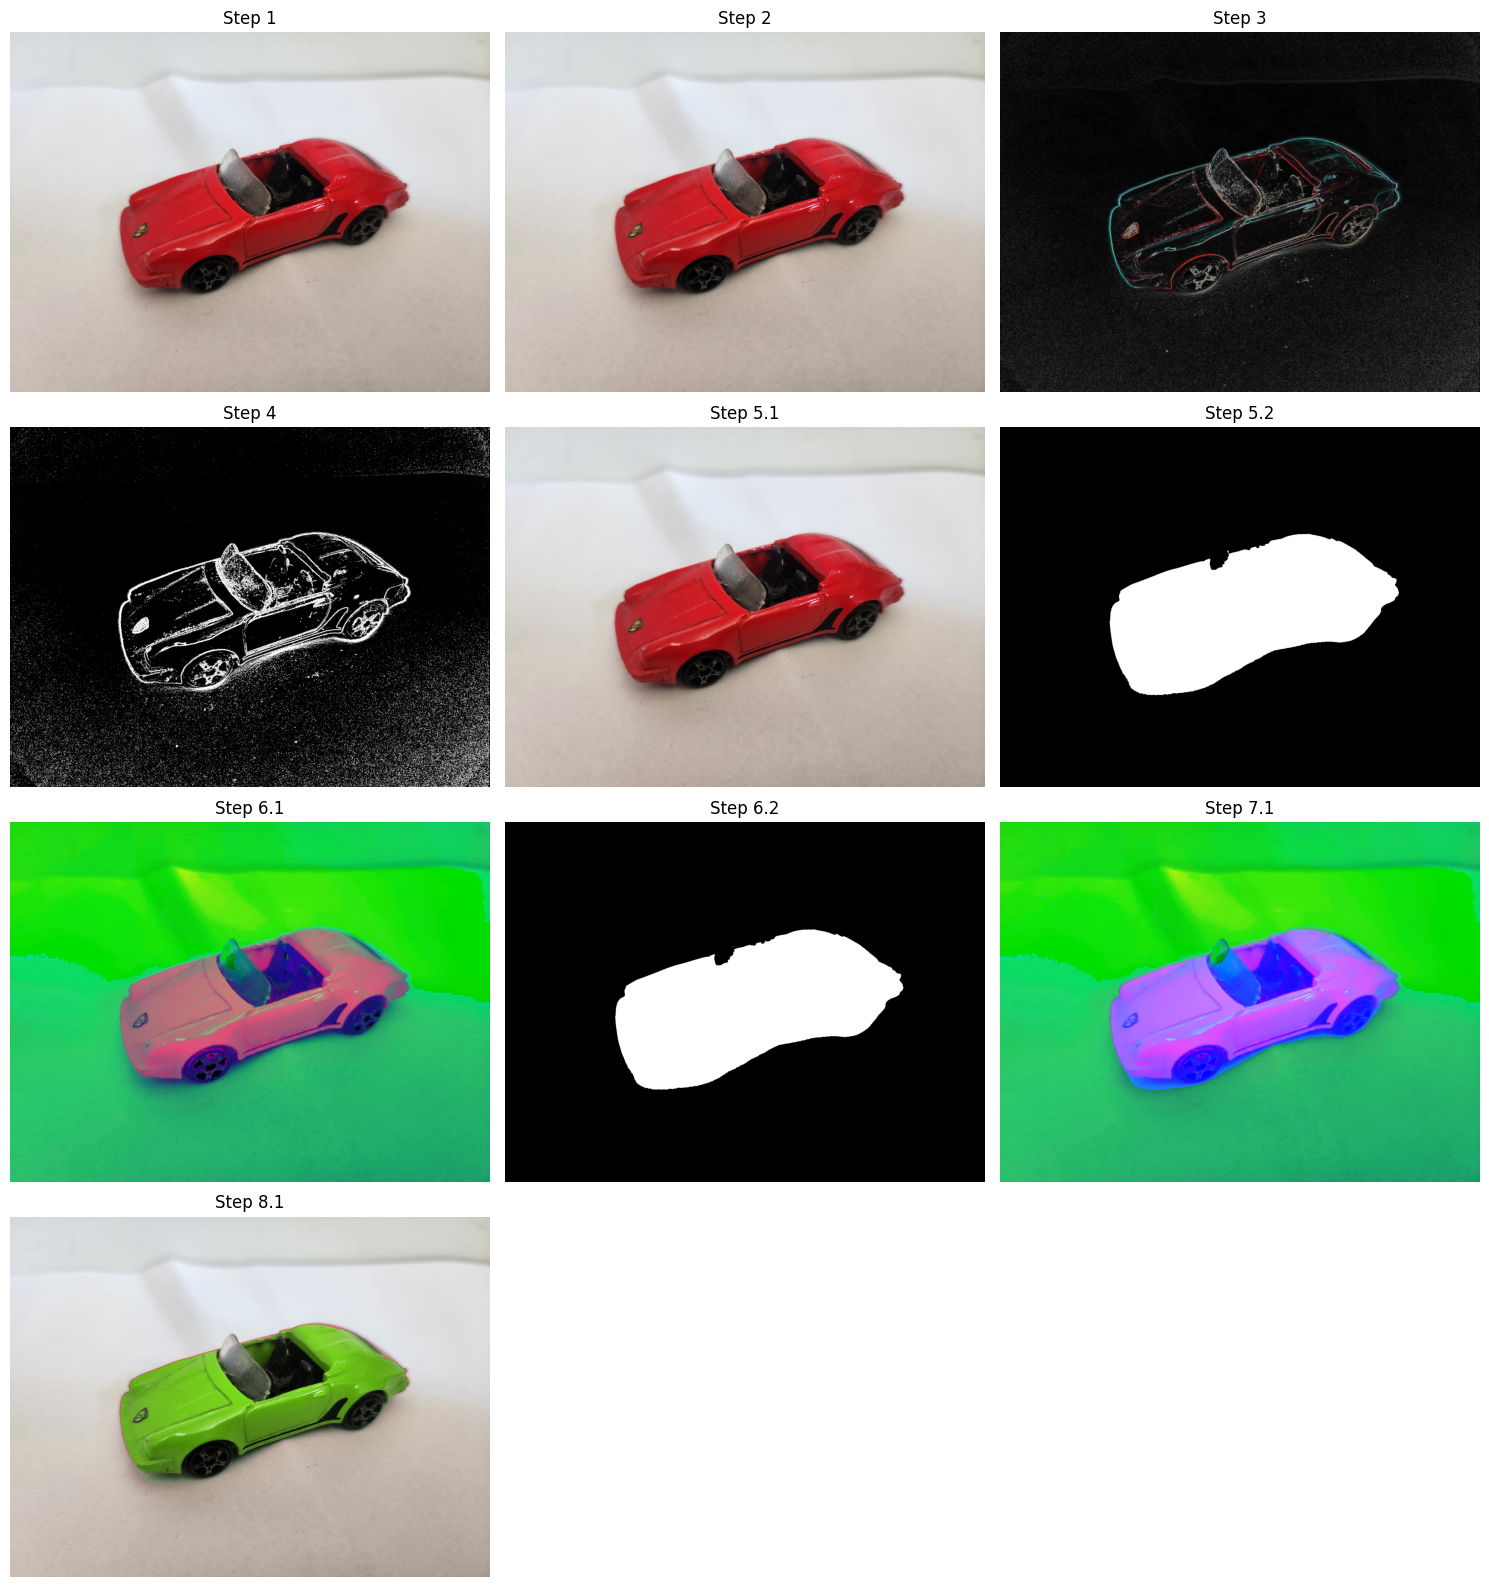

In [ ]:
img = cv2.imread("./images/20260314_115848.jpg", cv2.IMREAD_COLOR_BGR)
ShowAll(RunPipeline(img, pipeline))
